# DDQN12 candidate1

DDQN5 계열 보상 미세조정 + auxiliary margin/ranking loss + 목표형 threshold 선택 버전.
목표는 Q-margin 순위 자체를 개선하여 TP를 유지하면서 FP를 줄이는 것입니다.

In [1]:
# 랜덤성 제어를 위한 표준 라이브러리 모듈을 불러옵니다.
import random
from collections import deque
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import MinMaxScaler


# 데이터셋을 불러옵니다.
dat = pd.read_csv(Path("../../data/processed/data_selected.csv"), index_col=0)

# 재현 가능한 실험을 위해 시드 값을 고정합니다.
SEED = 1
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# GPU가 있으면 CUDA를, 없으면 CPU를 사용하도록 장치를 설정합니다.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# DDQN에서 사용할 Q-Network 구조를 정의합니다.
# 데이터 수가 많지 않으므로 과적합 가능성을 염두에 두고 2개 은닉층을 사용합니다.
class QNetwork(nn.Module):
    def __init__(self, state_dim: int, action_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 96),
            nn.ReLU(),
            nn.Linear(96, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim),
        )

    def forward(self, x):
        return self.net(x)                         # (batch, 2)

# 경험을 저장하고 무작위 샘플링하기 위한 리플레이 버퍼를 정의합니다.
class ReplayBuffer:
    def __init__(self, capacity: int):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done, label):
        # label을 같이 저장해야 auxiliary margin/ranking loss에서 실제 class를 사용할 수 있음
        self.buffer.append((state, action, reward, next_state, done, label))

    def sample(self, batch_size: int):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones, labels = map(np.array, zip(*batch))
        return (
            torch.FloatTensor(states).to(device),
            torch.LongTensor(actions).unsqueeze(1).to(device),
            torch.FloatTensor(rewards).unsqueeze(1).to(device),
            torch.FloatTensor(next_states).to(device),
            torch.FloatTensor(dones.astype(np.float32)).unsqueeze(1).to(device),
            torch.LongTensor(labels.astype(np.int64)).to(device),
        )

    def __len__(self):
        return len(self.buffer)


# DDQN 에이전트를 정의합니다.
class DDQNAgent:
    def __init__(
        self,
        state_dim,
        action_dim,
        gamma=0.95,
        lr=5e-4,
        batch_size=64,
        memory_size=100_000,
        target_update=2000,
        epsilon_start=1.0,
        epsilon_end=0.05,
        epsilon_decay=0.995,
        cls_lambda=0.08,
        rank_lambda=0.15,
        rank_margin=0.30,
        pos_weight=2.5,
    ):
        self.action_dim = action_dim
        self.gamma = gamma
        self.batch_size = batch_size
        self.target_update = target_update

        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay

        # Auxiliary margin/ranking loss 설정
        # 목적: Q-margin 순위 자체를 개선해서 hard negative(FP)를 아래로 밀고, positive(TP)를 위로 올림
        self.cls_lambda = cls_lambda
        self.rank_lambda = rank_lambda
        self.rank_margin = rank_margin
        self.pos_weight = torch.tensor([pos_weight], dtype=torch.float32, device=device)

        self.online_net = QNetwork(state_dim, action_dim).to(device)
        self.target_net = QNetwork(state_dim, action_dim).to(device)
        self.target_net.load_state_dict(self.online_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.online_net.parameters(), lr=lr)
        self.memory = ReplayBuffer(memory_size)
        self.total_steps = 0

    def act(self, state, epsilon: float = None):
        if epsilon is None:
            epsilon = self.epsilon

        if random.random() < epsilon:
            return random.randrange(self.action_dim)

        state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
        with torch.no_grad():
            q_values = self.online_net(state_t)
        return int(torch.argmax(q_values, dim=1).item())

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)

    def update(self):
        if len(self.memory) < self.batch_size:
            return None

        states, actions, rewards, next_states, dones, labels = self.memory.sample(self.batch_size)

        # -----------------------------
        # 1) 기본 DDQN TD loss
        # -----------------------------
        q_all = self.online_net(states)
        q_values = q_all.gather(1, actions)

        next_actions = self.online_net(next_states).argmax(dim=1, keepdim=True)
        next_q_values = self.target_net(next_states).gather(1, next_actions)
        target_q = rewards + (1 - dones) * self.gamma * next_q_values
        td_loss = F.mse_loss(q_values, target_q.detach())

        # -----------------------------
        # 2) Auxiliary margin classification loss
        #    margin = Q(High) - Q(Low)
        #    y=1이면 margin을 올리고, y=0이면 margin을 내림
        # -----------------------------
        margins = q_all[:, 1] - q_all[:, 0]
        labels_float = labels.float()
        cls_loss = F.binary_cross_entropy_with_logits(
            margins,
            labels_float,
            pos_weight=self.pos_weight
        )

        # -----------------------------
        # 3) Hard ranking loss
        #    batch 내부에서 positive margin이 hard negative margin보다
        #    rank_margin만큼 크도록 강제
        #    -> TP를 유지하면서 FP를 줄이는 데 핵심
        # -----------------------------
        pos_margins = margins[labels == 1]
        neg_margins = margins[labels == 0]

        if len(pos_margins) > 0 and len(neg_margins) > 0:
            # 어려운 positive: margin이 낮은 positive
            # 어려운 negative: margin이 높은 negative
            k_pos = min(16, len(pos_margins))
            k_neg = min(32, len(neg_margins))
            hard_pos = torch.topk(pos_margins, k=k_pos, largest=False).values
            hard_neg = torch.topk(neg_margins, k=k_neg, largest=True).values
            pairwise_gap = hard_pos.unsqueeze(1) - hard_neg.unsqueeze(0)
            rank_loss = F.relu(self.rank_margin - pairwise_gap).mean()
        else:
            rank_loss = torch.tensor(0.0, device=device)

        loss = td_loss + self.cls_lambda * cls_loss + self.rank_lambda * rank_loss

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.online_net.parameters(), max_norm=10.0)
        self.optimizer.step()

        self.total_steps += 1
        if self.total_steps % self.target_update == 0:
            self.target_net.load_state_dict(self.online_net.state_dict())

        return float(loss.item())

def encode_risk_labels(series):
    s = series.copy()
    # 문자열 타입이면 'High Risk' → 1, 'Low Risk' → 0 매핑
    if pd.api.types.is_object_dtype(s) or pd.api.types.is_string_dtype(s):
        s = s.map({'Low Risk': 0, 'High Risk': 1})
        if s.isna().any():
            raise ValueError(f"알 수 없는 라벨 값이 있습니다: {series[s.isna()].unique()}")
    # 숫자형이면 그냥 int 변환
    return s.fillna(0).astype(int).to_numpy()

# ---- 데이터 준비 (Train/Valid/Test Split 먼저, 그 후 Scaling) ----

risk_label_col = "Risk_Label"
feature_cols = [c for c in dat.select_dtypes(include=[np.number]).columns if c != risk_label_col]
if len(feature_cols) == 0:
    raise ValueError("학습에 사용할 수치형 feature가 없습니다.")

risk_label_data = encode_risk_labels(dat[risk_label_col])
feature_data_raw = dat[feature_cols].fillna(0.0).to_numpy()
n_steps = len(dat)

train_end = int(n_steps * 0.45)
valid_end = int(n_steps * 0.80)

train_indices = np.arange(0, train_end)
valid_indices = np.arange(train_end, valid_end)
test_indices  = np.arange(valid_end, n_steps)

train_feature_raw = feature_data_raw[train_indices]
train_label = risk_label_data[train_indices]

valid_feature_raw = feature_data_raw[valid_indices]
valid_label = risk_label_data[valid_indices]
if len(valid_label) < 2:
    raise ValueError("Validation set 길이가 너무 짧아 tuning/selection 분할이 불가능합니다. split 비율을 조정하세요.")
valid_split_point = int(len(valid_label) * 0.65)
valid_tune_feature_raw = valid_feature_raw[:valid_split_point]
valid_tune_label = valid_label[:valid_split_point]
valid_select_feature_raw = valid_feature_raw[valid_split_point:]
valid_select_label = valid_label[valid_split_point:]

test_feature_raw = feature_data_raw[test_indices]
test_label = risk_label_data[test_indices]

def summarize_class_ratio(name, y):
    n_total = len(y)
    n0 = int((y == 0).sum())
    n1 = int((y == 1).sum())
    r0 = n0 / n_total if n_total > 0 else 0.0
    r1 = n1 / n_total if n_total > 0 else 0.0
    imbalance = (n1 / max(n0, 1)) if n_total > 0 else 0.0
    print(f"{name:>5} | n={n_total:4d} | class0={n0:4d} ({r0:.2%}) | class1={n1:4d} ({r1:.2%}) | c1/c0={imbalance:.4f})")
    if n0 == 0 or n1 == 0:
        raise ValueError(f"{name} set에 클래스 0 또는 1이 없습니다. split 비율 또는 기간을 조정하세요.")

print("Class Ratio Summary (Before ADASYN)")
summarize_class_ratio("Train", train_label)
summarize_class_ratio("ValTun", valid_tune_label)
summarize_class_ratio("ValSel", valid_select_label)
summarize_class_ratio("Test", test_label)

# 보상 계산에 사용할 class_ratio는 원본 train 기준으로 고정합니다.
n_negative_original = (train_label == 0).sum()
n_positive_original = (train_label == 1).sum()
class_ratio_reward = n_positive_original / max(n_negative_original, 1)
print(f"Reward class ratio (original train): {class_ratio_reward:.4f}")

# ---- ADASYN을 적용하지 않고 원본 학습 데이터를 그대로 사용 ----
train_feature = train_feature_raw.astype(np.float32)
train_label = train_label.astype(np.int64)

scaler = MinMaxScaler()
scaler.fit(train_feature)

train_feature = scaler.transform(train_feature).astype(np.float32)
valid_tune_feature = scaler.transform(valid_tune_feature_raw).astype(np.float32)
valid_select_feature = scaler.transform(valid_select_feature_raw).astype(np.float32)
test_feature = scaler.transform(test_feature_raw).astype(np.float32)

print("=" * 60)
print("Data Split Information")
print("=" * 60)
print(f"Total samples: {n_steps}")
print(f"Train set: {len(train_label)} samples")
print(f"  - Class 0: {(train_label==0).sum()}, Class 1: {(train_label==1).sum()}")
print(f"Valid(Tune) set: {len(valid_tune_label)} samples")
print(f"  - Class 0: {(valid_tune_label==0).sum()}, Class 1: {(valid_tune_label==1).sum()}")
print(f"Valid(Select) set: {len(valid_select_label)} samples")
print(f"  - Class 0: {(valid_select_label==0).sum()}, Class 1: {(valid_select_label==1).sum()}")
test_ratio = len(test_label) / n_steps
print(f"Test set: {len(test_label)} samples ({test_ratio*100:.1f}%)")
print(f"  - Class 0: {(test_label==0).sum()}, Class 1: {(test_label==1).sum()}")

# 원본 학습 세트의 클래스 비율을 그대로 사용합니다.
n_negative = (train_label == 0).sum()
n_positive = (train_label == 1).sum()
class_ratio = class_ratio_reward

print(f"\nClass ratio (train set): {n_positive / max(n_negative, 1):.4f}")
print(f"Class ratio used for reward: {class_ratio:.4f}")
print("=" * 60)

state_dim = len(feature_cols)
action_dim = 2

def compute_reward(action, actual_label, class_ratio):
    action = int(action)
    actual_label = int(actual_label)
    if actual_label == 0:
        if action == 0:
            return class_ratio
        else:
            return -0.46            # FP: DDQN5(-0.45)보다 아주 약하게 강화
    else:
        if action == 1:
            return 1.33             # TP: DDQN5(1.30)보다 아주 약하게 강화
        else:
            return -1.23            # FN: DDQN5(-1.20)보다 아주 약하게 강화
        
# train_label에서 High Risk 인덱스를 미리 계산
high_risk_indices = np.where(train_label == 1)[0]
print(f"High Risk 인덱스 수 (train): {len(high_risk_indices)}")

def get_balanced_start_idx(max_steps, high_risk_prob=0.5):
    """
    high_risk_prob 확률로 High Risk가 윈도우 안에
    반드시 포함되는 start_idx를 반환.
    
    나머지 확률로는 기존 랜덤 방식 사용.
    시계열 순서는 항상 유지됨.
    
    Parameters:
        max_steps: 에피소드 길이 (500)
        high_risk_prob: High Risk 포함 윈도우 선택 확률
    
    Returns:
        start_idx: 에피소드 시작 인덱스
    """
    n = len(train_feature)
    max_start = n - max_steps - 1
    
    if np.random.random() < high_risk_prob:
        # High Risk 인덱스 중 하나를 무작위 선택
        hr_idx = np.random.choice(high_risk_indices)
        
        # 이 hr_idx가 윈도우 안에 포함되는
        # start_idx의 유효 범위 계산:
        # 조건: start_idx <= hr_idx <= start_idx + max_steps - 1
        # → low = hr_idx - max_steps + 1
        # → high = hr_idx
        low  = max(0, hr_idx - max_steps + 1)
        high = min(max_start, hr_idx)
        
        if low > high:
            # 유효 범위가 없으면 (데이터 끝부분 등) 랜덤
            return np.random.randint(0, max_start + 1)
        
        # 유효 범위 안에서 랜덤 선택
        # → High Risk가 윈도우 앞/중간/뒤 어디든 포함됨
        return int(np.random.randint(low, high + 1))
    
    else:
        # 기존 방식: 완전 랜덤
        return int(np.random.randint(0, max_start + 1))

Class Ratio Summary (Before ADASYN)
Train | n=1848 | class0=1638 (88.64%) | class1= 210 (11.36%) | c1/c0=0.1282)
ValTun | n= 934 | class0= 829 (88.76%) | class1= 105 (11.24%) | c1/c0=0.1267)
ValSel | n= 504 | class0= 427 (84.72%) | class1=  77 (15.28%) | c1/c0=0.1803)
 Test | n= 822 | class0= 723 (87.96%) | class1=  99 (12.04%) | c1/c0=0.1369)
Reward class ratio (original train): 0.1282
Data Split Information
Total samples: 4108
Train set: 1848 samples
  - Class 0: 1638, Class 1: 210
Valid(Tune) set: 934 samples
  - Class 0: 829, Class 1: 105
Valid(Select) set: 504 samples
  - Class 0: 427, Class 1: 77
Test set: 822 samples (20.0%)
  - Class 0: 723, Class 1: 99

Class ratio (train set): 0.1282
Class ratio used for reward: 0.1282
High Risk 인덱스 수 (train): 210



HYPERPARAMETER GRID SEARCH (Total: 12 combinations)

[1/12] gamma=0.85, lr=5e-05, eps_decay=0.995, bs=32
  Ep  20 | Tune G-mean: 0.5429 F1: 0.2966 (Sens: 0.3333, Spec: 0.8842, Pre: 0.2672) | Best G-mean: 0.5634
  Ep  40 | Tune G-mean: 0.5436 F1: 0.2991 (Sens: 0.3333, Spec: 0.8866, Pre: 0.2713) | Best G-mean: 0.5634
  Ep  60 | Tune G-mean: 0.5597 F1: 0.3162 (Sens: 0.3524, Spec: 0.8890, Pre: 0.2868) | Best G-mean: 0.5760
  Ep  80 | Tune G-mean: 0.5521 F1: 0.3090 (Sens: 0.3429, Spec: 0.8890, Pre: 0.2812) | Best G-mean: 0.5796
  Ep 100 | Tune G-mean: 0.5840 F1: 0.3267 (Sens: 0.3905, Spec: 0.8733, Pre: 0.2808) | Best G-mean: 0.6033
  Ep 120 | Tune G-mean: 0.5589 F1: 0.3136 (Sens: 0.3524, Spec: 0.8866, Pre: 0.2824) | Best G-mean: 0.6033
  Ep 140 | Tune G-mean: 0.5872 F1: 0.3374 (Sens: 0.3905, Spec: 0.8830, Pre: 0.2971) | Best G-mean: 0.6033
  Ep 160 | Tune G-mean: 0.5261 F1: 0.3005 (Sens: 0.3048, Spec: 0.9083, Pre: 0.2963) | Best G-mean: 0.6033
  Ep 180 | Tune G-mean: 0.5631 F1: 0.3289 (Sen

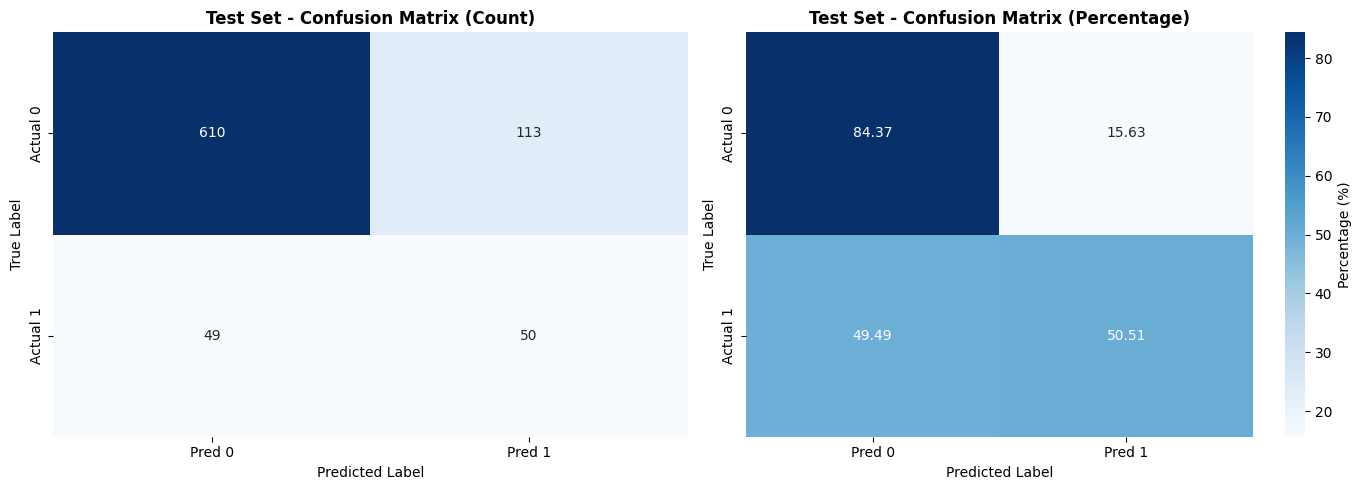


상세 메트릭 (Test Set):
Sensitivity (Recall for Class 1): 0.5051
Specificity (Recall for Class 0): 0.8437
Precision (Class 1):              0.3067
F1-Score:                         0.3817
G-mean:                           0.6528

VALIDATION SET vs TEST SET 성능 비교

Validation(Selection) Set - G-mean: 0.6673
Test Set - G-mean: 0.6528
Difference (Valid - Test): 0.0145

Validation Confusion Matrix:
[[305 122]
 [ 29  48]]

Test Confusion Matrix:
[[610 113]
 [ 49  50]]


In [2]:
# ---- Validation 기반 하이퍼파라미터 Grid Search ----
from itertools import product

param_grid = {
    "gamma": [0.85, 0.90, 0.95, 0.99],
    "lr": [5e-5, 1e-4, 2e-4],
    "epsilon_decay": [0.995],
    "batch_size": [32]
}

# 성능 지표 함수: G-Mean 기준으로 튜닝

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    precision = tp /(tp+fp) if (tp + fp) > 0 else 0.0

    gmean = float(np.sqrt(sensitivity * specificity))
    f1 =float(2 * (precision * sensitivity) / (precision + sensitivity)) if (precision + sensitivity) > 0 else 0.0

    return gmean, f1, sensitivity, specificity, precision

def predict_labels_argmax(model, features):
    preds = []
    with torch.no_grad():
        for t in range(len(features)):
            state_t = torch.FloatTensor(features[t]).unsqueeze(0).to(device)
            q_values = model(state_t)
            preds.append(int(torch.argmax(q_values, dim=1).item()))
    return np.array(preds)

def evaluate_argmax(model, x_valid, y_valid):
    preds = predict_labels_argmax(model, x_valid)
    gmean, f1, sensitivity, specificity, precision = compute_metrics(y_valid, preds)
    return gmean, f1, sensitivity, specificity, precision


def get_q_margin(model, features, batch_size=2048):
    """
    Q-margin = Q(High Risk) - Q(Low Risk)
    값이 클수록 High Risk(class 1)로 판단할 근거가 큽니다.
    """
    model.eval()
    margins = []

    with torch.no_grad():
        for start in range(0, len(features), batch_size):
            x_batch = torch.FloatTensor(features[start:start + batch_size]).to(device)
            q_values = model(x_batch).cpu().numpy()
            q_margin = q_values[:, 1] - q_values[:, 0]
            margins.append(q_margin)

    return np.concatenate(margins)


def predict_by_q_threshold(model, features, threshold):
    margins = get_q_margin(model, features)
    return (margins >= threshold).astype(int)


def select_threshold_by_recall_fp(model, x_valid, y_valid, recall_floor=0.62):
    """
    valid_select 기준 Q-margin threshold 선택.

    선택 기준:
    1) Recall >= recall_floor 후보 유지
    2) 그중 FP 최소
    3) Precision 최대
    4) G-Mean 최대
    5) F1 최대

    주의: 이 함수는 valid_select에서만 threshold를 고르는 용도이며,
    test set은 최종 평가에만 사용합니다.
    """
    margins = get_q_margin(model, x_valid)

    # 실제 예측이 바뀌는 지점과 argmax 기준(threshold=0)을 후보로 사용합니다.
    threshold_grid = np.unique(np.r_[margins, 0.0])
    records = []

    for th in threshold_grid:
        pred = (margins >= th).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_valid, pred, labels=[0, 1]).ravel()

        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        f1 = (
            2 * precision * sensitivity / (precision + sensitivity)
            if (precision + sensitivity) > 0 else 0.0
        )
        gmean = float(np.sqrt(sensitivity * specificity))

        records.append({
            "threshold": float(th),
            "tn": int(tn),
            "fp": int(fp),
            "fn": int(fn),
            "tp": int(tp),
            "sensitivity": float(sensitivity),
            "specificity": float(specificity),
            "precision": float(precision),
            "f1": float(f1),
            "gmean": float(gmean),
        })

    threshold_search_df = pd.DataFrame(records)

    candidate_df = threshold_search_df[
        threshold_search_df["sensitivity"] >= recall_floor
    ].copy()

    # recall 조건을 만족하는 threshold가 없으면 G-Mean 중심으로 fallback합니다.
    fallback_used = False
    if candidate_df.empty:
        fallback_used = True
        candidate_df = threshold_search_df.sort_values(
            by=["gmean", "sensitivity", "fp", "precision", "f1", "tp"],
            ascending=[False, False, True, False, False, False]
        ).reset_index(drop=True)
    else:
        candidate_df = candidate_df.sort_values(
            by=["fp", "precision", "gmean", "f1", "tp"],
            ascending=[True, False, False, False, False]
        ).reset_index(drop=True)

    best = candidate_df.iloc[0].to_dict()
    best["recall_floor"] = float(recall_floor)
    best["fallback_used"] = bool(fallback_used)

    return best, threshold_search_df, candidate_df



def select_threshold_by_target_tradeoff(
    model,
    x_valid,
    y_valid,
    target_recall=0.66,
    target_fpr=0.21,
    min_recall=0.62,
):
    """
    valid_select 기준 목표형 threshold 선택.

    목표는 test에서 대략 TP>=65, FP≈150을 노리는 방향이지만,
    test를 직접 보지 않기 위해 valid_select에서 다음 비율 목표로 고른다.

    - target_recall ≈ 65 / 99 = 0.6566
    - target_fpr    ≈ 150 / 723 = 0.2075

    선택 방식:
    1) Recall >= min_recall 후보 우선
    2) target_recall과 target_fpr에 가장 가까운 threshold 선택
    3) 동률이면 G-Mean, F1, Precision 순으로 선택
    """
    margins = get_q_margin(model, x_valid)
    threshold_grid = np.unique(np.r_[margins, 0.0])
    records = []

    for th in threshold_grid:
        pred = (margins >= th).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_valid, pred, labels=[0, 1]).ravel()

        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        f1 = (
            2 * precision * sensitivity / (precision + sensitivity)
            if (precision + sensitivity) > 0 else 0.0
        )
        gmean = float(np.sqrt(sensitivity * specificity))
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

        # target에서 멀수록 큰 penalty
        # FPR을 더 강하게 본다. 그래야 FP가 줄어드는 방향으로 threshold가 잡힘.
        target_distance = (
            ((sensitivity - target_recall) / 0.06) ** 2
            + 1.75 * ((fpr - target_fpr) / 0.06) ** 2
        )

        records.append({
            "threshold": float(th),
            "tn": int(tn),
            "fp": int(fp),
            "fn": int(fn),
            "tp": int(tp),
            "sensitivity": float(sensitivity),
            "specificity": float(specificity),
            "precision": float(precision),
            "f1": float(f1),
            "gmean": float(gmean),
            "fpr": float(fpr),
            "target_distance": float(target_distance),
        })

    threshold_search_df = pd.DataFrame(records)

    candidate_df = threshold_search_df[threshold_search_df["sensitivity"] >= min_recall].copy()
    fallback_used = False
    if candidate_df.empty:
        candidate_df = threshold_search_df.copy()
        fallback_used = True

    candidate_df = candidate_df.sort_values(
        by=["target_distance", "gmean", "f1", "precision", "tp", "fp"],
        ascending=[True, False, False, False, False, True]
    ).reset_index(drop=True)

    best = candidate_df.iloc[0].to_dict()
    best["target_recall"] = float(target_recall)
    best["target_fpr"] = float(target_fpr)
    best["min_recall"] = float(min_recall)
    best["fallback_used"] = bool(fallback_used)

    return best, threshold_search_df, candidate_df


#그리드 서치 학습 =============================================
grid_search_results = []
param_combinations = list(product(*param_grid.values()))
param_names = list(param_grid.keys())

print("\n" + "=" * 80)
print(f"HYPERPARAMETER GRID SEARCH (Total: {len(param_combinations)} combinations)")
print("=" * 80)

patience = 25
min_episodes = 60
best_overall_select_gmean = -1.0
best_overall_params = None

for idx, params in enumerate(param_combinations):
    param_dict = dict(zip(param_names, params))
    gamma, lr, epsilon_decay, batch_size = params
    # 각 조합마다 동일한 초기 조건으로 시작
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    print(f"\n[{idx+1}/{len(param_combinations)}] gamma={gamma:.2f}, lr={lr:.0e}, eps_decay={epsilon_decay:.3f}, bs={batch_size}")

    agent_tune = DDQNAgent(
        state_dim=state_dim,
        action_dim=action_dim,
        gamma=gamma,
        lr=lr,
        batch_size=batch_size,
        memory_size=50_000,
        target_update=2000,
        epsilon_start=1.0,
        epsilon_end=0.05,
        epsilon_decay=epsilon_decay,
        cls_lambda=0.08,
        rank_lambda=0.15,
        rank_margin=0.30,
        pos_weight=2.5,
    )

    episodes_tune = 200
    max_steps_tune = 500
    best_tune_gmean = -1.0
    best_tune_state_dict = None
    patience_counter = 0

    for ep in range(1, episodes_tune + 1):
        start_idx = get_balanced_start_idx(max_steps_tune, high_risk_prob=0.5)
        episode_reward = 0.0

        for i in range(max_steps_tune):
            state = train_feature[start_idx + i]
            next_state = train_feature[start_idx + i + 1] if start_idx + i + 1 < len(train_feature) else train_feature[start_idx + i]
            actual_label = train_label[start_idx + i]

            action = agent_tune.act(state)
            reward = compute_reward(action, actual_label, class_ratio)
            done = i == (max_steps_tune - 1)

            agent_tune.memory.push(state, action, reward, next_state, done, actual_label)
            _ = agent_tune.update()
            episode_reward += reward

        agent_tune.decay_epsilon()

    # 5 에피소드마다 tune 데이터로 검증을 수행하여 G-mean이 개선되는지 확인=================================
        if ep % 5 == 0:
            agent_tune.online_net.eval()
            tune_gmean, tune_f1, tune_sensitivity, tune_specificity, tune_precision = evaluate_argmax(
                agent_tune.online_net, valid_tune_feature, valid_tune_label
            )
            agent_tune.online_net.train()

            if tune_gmean > best_tune_gmean:
                best_tune_gmean = tune_gmean
                patience_counter = 0
                best_tune_state_dict = {k: v.detach().cpu().clone() for k, v in agent_tune.online_net.state_dict().items()}
            else:
                patience_counter += 1

            if ep % 20 == 0:
                print(f"  Ep {ep:3d} | Tune G-mean: {tune_gmean:.4f} F1: {tune_f1:.4f} (Sens: {tune_sensitivity:.4f}, Spec: {tune_specificity:.4f}, Pre: {tune_precision:.4f}) | Best G-mean: {best_tune_gmean:.4f}")

            if ep > min_episodes and patience_counter >= patience:
                break
# Tune에서 가장 좋은 모델로 Selection 데이터에 대한 최종 평가를 수행합니다====================

    agent_tune.online_net.eval()
    if best_tune_state_dict is not None:
        agent_tune.online_net.load_state_dict(best_tune_state_dict)
    select_gmean, select_f1, select_sensitivity, select_specificity, select_precision = evaluate_argmax(
        agent_tune.online_net, valid_select_feature, valid_select_label
    )

    grid_search_results.append({
        'params': param_dict,
        'best_tune_gmean': best_tune_gmean,
        'select_gmean': select_gmean,
        'select_f1': select_f1,
        'select_sensitivity': select_sensitivity,
        'select_specificity': select_specificity,
        'select_precision': select_precision
    })

    if select_gmean > best_overall_select_gmean:
        best_overall_select_gmean = select_gmean
        best_overall_params = param_dict

grid_search_results.sort(key=lambda x: x['select_gmean'], reverse=True)

print("\n" + "=" * 80)
print("TOP 5 HYPERPARAMETERS")
print("=" * 80)
for i, result in enumerate(grid_search_results[:5]):
    print(f"{i+1}. "
          f"G-mean: {result['select_gmean']:.4f} | "
          f"F1: {result['select_f1']:.4f} | "
          f"Prec: {result['select_precision']:.4f} | "
          f"Params: {result['params']}")

print("\n" + "=" * 80)
print("BEST HYPERPARAMETERS")
print("=" * 80)
for k, v in best_overall_params.items():
    print(f"{k}: {v}")
print(f"Best Selection G-mean: {best_overall_select_gmean:.4f}")
print("=" * 80)

# ---- 최적 파라미터로 본 학습 ----
print("\nTraining with best hyperparameters...")
agent = DDQNAgent(
    state_dim=state_dim,
    action_dim=action_dim,
    gamma=best_overall_params['gamma'],
    lr=best_overall_params['lr'],
    batch_size=best_overall_params['batch_size'],
    memory_size=50_000,
    target_update=2000,
    epsilon_start=1.0,
    epsilon_end=0.05,
    epsilon_decay=best_overall_params['epsilon_decay'],
    cls_lambda=0.08,
    rank_lambda=0.15,
    rank_margin=0.30,
    pos_weight=2.5,
)

episodes = 800
max_steps = 500
scores = []
valid_scores = []
best_ckpt_valid_gmean = -1.0
best_ckpt_epoch = 0
best_ckpt_state_dict = None

for ep in range(1, episodes + 1):
    episode_reward = 0.0
    start_idx = get_balanced_start_idx(max_steps, high_risk_prob=0.5)

    for i in range(max_steps):
        state = train_feature[start_idx + i]
        next_state = train_feature[start_idx + i + 1] if start_idx + i + 1 < len(train_feature) else train_feature[start_idx + i]
        actual_label = train_label[start_idx + i]

        action = agent.act(state)
        reward = compute_reward(action, actual_label, class_ratio)
        done = i == (max_steps - 1)

        agent.memory.push(state, action, reward, next_state, done, actual_label)
        _ = agent.update()
        episode_reward += reward

    agent.decay_epsilon()
    scores.append(episode_reward)

    if ep % 10 == 0:
        agent.online_net.eval()
        valid_gmean, valid_f1, valid_sensitivity, valid_specificity, valid_precision = evaluate_argmax(
            agent.online_net, valid_select_feature, valid_select_label
        )
        valid_scores.append(valid_gmean)

        if valid_gmean > best_ckpt_valid_gmean:
            best_ckpt_valid_gmean = valid_gmean
            best_ckpt_epoch = ep
            best_ckpt_state_dict = {k: v.detach().cpu().clone() for k, v in agent.online_net.state_dict().items()}
        agent.online_net.train()

        print(f"Episode {ep:3d} | "f"Reward: {np.mean(scores[-10:]):8.5f} | "f"G-mean: {valid_gmean:.4f} | "f"F1: {valid_f1:.4f} | "f"Prec: {valid_precision:.4f} | "f"Best G-mean: {best_ckpt_valid_gmean:.4f}")

print("최종 학습 완료")
if best_ckpt_state_dict is not None:
    agent.online_net.load_state_dict(best_ckpt_state_dict)
    agent.target_net.load_state_dict(best_ckpt_state_dict)
    print(f"Best checkpoint restored: epoch={best_ckpt_epoch}, valid_gmean={best_ckpt_valid_gmean:.4f}")

agent.online_net.eval()

# ---- valid_select에서 Q-margin threshold 선택 ----
# 기준: 목표형 threshold 선택
# 목표: test 기준으로 TP>=65, FP≈150에 가까운 recall/FPR 구조를 valid_select에서 근사
threshold_info, threshold_search_df, threshold_candidate_df = select_threshold_by_target_tradeoff(
    agent.online_net,
    valid_select_feature,
    valid_select_label,
    target_recall=0.66,
    target_fpr=0.21,
    min_recall=0.62
)
Q_THRESHOLD = threshold_info["threshold"]

print("\n" + "=" * 60)
print("VALID Q-MARGIN THRESHOLD SELECTION")
print("=" * 60)
print(f"Target recall         = {threshold_info['target_recall']:.4f}")
print(f"Target FPR            = {threshold_info['target_fpr']:.4f}")
print(f"Minimum recall        = {threshold_info['min_recall']:.4f}")
print(f"Fallback used         = {threshold_info['fallback_used']}")
print(f"Target distance       = {threshold_info['target_distance']:.4f}")
print(f"Selected threshold    = {Q_THRESHOLD:.6f}")
print(
    f"Selected valid CM: "
    f"TN={int(threshold_info['tn'])}, FP={int(threshold_info['fp'])}, "
    f"FN={int(threshold_info['fn'])}, TP={int(threshold_info['tp'])}"
)
print(
    f"Valid Sens={threshold_info['sensitivity']:.4f}, "
    f"Spec={threshold_info['specificity']:.4f}, "
    f"Prec={threshold_info['precision']:.4f}, "
    f"F1={threshold_info['f1']:.4f}, "
    f"G-mean={threshold_info['gmean']:.4f}"
)
print("=" * 60)

# ---- Test 평가 ----
test_predictions = predict_by_q_threshold(agent.online_net, test_feature, Q_THRESHOLD)

cm_test = confusion_matrix(test_label, test_predictions, labels=[0, 1])
tn, fp, fn, tp = cm_test.ravel()
sensitivity_test = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity_test = tn / (tn + fp) if (tn + fp) > 0 else 0
gmean_test = np.sqrt(sensitivity_test * specificity_test)

print("\n" + "=" * 60)
print("TEST SET - DDQN 분류 모델 최종 성능 평가")
print("=" * 60)
print(f"\nG-mean: {gmean_test:.4f}")
print(f"\nConfusion Matrix:")
print(cm_test)
print(f"\nTN: {cm_test[0, 0]}, FP: {cm_test[0, 1]}")
print(f"FN: {cm_test[1, 0]}, TP: {cm_test[1, 1]}")

print(f"\n분류 리포트:")
print(classification_report(test_label, test_predictions,
                          labels=[0, 1],
                          target_names=['Class 0 (Negative)', 'Class 1 (Positive)'],
                          zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax1,
            xticklabels=['Pred 0', 'Pred 1'],
            yticklabels=['Actual 0', 'Actual 1'])
ax1.set_title('Test Set - Confusion Matrix (Count)', fontsize=12, fontweight='bold')
ax1.set_ylabel('True Label')
ax1.set_xlabel('Predicted Label')

cm_test_row_sums = cm_test.sum(axis=1, keepdims=True)
cm_test_percent = np.divide(cm_test.astype(float), cm_test_row_sums,
                             out=np.zeros_like(cm_test, dtype=float),
                             where=cm_test_row_sums != 0) * 100
ax2 = axes[1]
sns.heatmap(cm_test_percent, annot=True, fmt='.2f', cmap='Blues', cbar=True, ax=ax2,
            xticklabels=['Pred 0', 'Pred 1'],
            yticklabels=['Actual 0', 'Actual 1'],
            cbar_kws={'label': 'Percentage (%)'})
ax2.set_title('Test Set - Confusion Matrix (Percentage)', fontsize=12, fontweight='bold')
ax2.set_ylabel('True Label')
ax2.set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
f1_score_val = 2 * (precision * sensitivity_test) / (precision + sensitivity_test) if (precision + sensitivity_test) > 0 else 0


print(f"\n상세 메트릭 (Test Set):")
print(f"Sensitivity (Recall for Class 1): {sensitivity_test:.4f}")
print(f"Specificity (Recall for Class 0): {specificity_test:.4f}")
print(f"Precision (Class 1):              {precision:.4f}")
print(f"F1-Score:                         {f1_score_val:.4f}")
print(f"G-mean:                           {gmean_test:.4f}")
print("=" * 60)

print("\n" + "=" * 60)
print("VALIDATION SET vs TEST SET 성능 비교")
print("=" * 60)

agent.online_net.eval()
valid_predictions = predict_by_q_threshold(agent.online_net, valid_select_feature, Q_THRESHOLD)
cm_valid = confusion_matrix(valid_select_label, valid_predictions, labels=[0, 1])
tn_v, fp_v, fn_v, tp_v = cm_valid.ravel()
sensitivity_valid = tp_v / (tp_v + fn_v) if (tp_v + fn_v) > 0 else 0
specificity_valid = tn_v / (tn_v + fp_v) if (tn_v + fp_v) > 0 else 0
gmean_valid = np.sqrt(sensitivity_valid * specificity_valid)

print(f"\nValidation(Selection) Set - G-mean: {gmean_valid:.4f}")
print(f"Test Set - G-mean: {gmean_test:.4f}")
print(f"Difference (Valid - Test): {gmean_valid - gmean_test:.4f}")
print("\nValidation Confusion Matrix:")
print(cm_valid)
print("\nTest Confusion Matrix:")
print(cm_test)
print("=" * 60)

전체 threshold frontier 요약
전체 threshold 후보 수: 824
Test 실제 class 1 개수: 99
TP 최소 조건: TP >= 65

[현재 Q_THRESHOLD 기준 결과]
Q_THRESHOLD = -0.040899
TN=610, FP=113, FN=49, TP=50
Sens=0.5051, Spec=0.8437, Prec=0.3067, F1=0.3817, G-mean=0.6528

TP >= 65 조건을 만족하는 threshold 후보

[TP 조건 유지하에서 FP 최소 threshold]
threshold = -0.191561
TN=535, FP=188, FN=34, TP=65
Sens=0.6566, Spec=0.7400, Prec=0.2569, F1=0.3693, G-mean=0.6970

[TP >= 65 조건에서 FP가 낮은 상위 20개 후보]


,threshold,tn,fp,fn,tp,sensitivity,specificity,precision,f1,gmean,pred_1_count
563,-0.191561,535,188,34,65,0.656566,0.739972,0.256917,0.369318,0.697023,253
564,-0.191877,534,189,34,65,0.656566,0.738589,0.255906,0.368272,0.696371,254
565,-0.194154,533,190,34,65,0.656566,0.737206,0.254902,0.367232,0.695718,255
566,-0.194182,532,191,34,65,0.656566,0.735823,0.253906,0.366197,0.695066,256
567,-0.194557,531,192,34,65,0.656566,0.734440,0.252918,0.365169,0.694412,257
568,-0.194666,530,193,34,65,0.656566,0.733057,0.251938,0.364146,0.693758,258
551,-0.196405,529,194,33,66,0.666667,0.731674,0.253846,0.367688,0.698414,260
569,-0.196392,529,194,34,65,0.656566,0.731674,0.250965,0.363128,0.693103,259
552,-0.196452,528,195,33,66,0.666667,0.730290,0.252874,0.366667,0.697754,261
553,-0.197082,527,196,33,66,0.666667,0.728907,0.251908,0.365651,0.697093,262



TP별 FP 최소 frontier


,tp,threshold,tn,fp,fn,sensitivity,specificity,precision,f1,gmean,pred_1_count
0,99,-0.849790,18,705,0,1.000000,0.024896,0.123134,0.219269,0.157786,804
1,98,-0.845620,18,705,1,0.989899,0.024896,0.122042,0.217295,0.156987,803
2,97,-0.808032,23,700,2,0.979798,0.031812,0.121706,0.216518,0.176548,797
3,96,-0.719307,65,658,3,0.969697,0.089903,0.127321,0.225088,0.295261,754
4,95,-0.689382,77,646,4,0.959596,0.106501,0.128205,0.226190,0.319684,741
5,94,-0.635777,111,612,5,0.949495,0.153527,0.133144,0.233540,0.381802,706
6,93,-0.615756,121,602,6,0.939394,0.167358,0.133813,0.234257,0.396504,695
7,92,-0.601227,130,593,7,0.929293,0.179806,0.134307,0.234694,0.408770,685
8,91,-0.540576,197,526,8,0.919192,0.272476,0.147488,0.254190,0.500457,617
9,90,-0.534046,206,517,9,0.909091,0.284924,0.148270,0.254958,0.508942,607


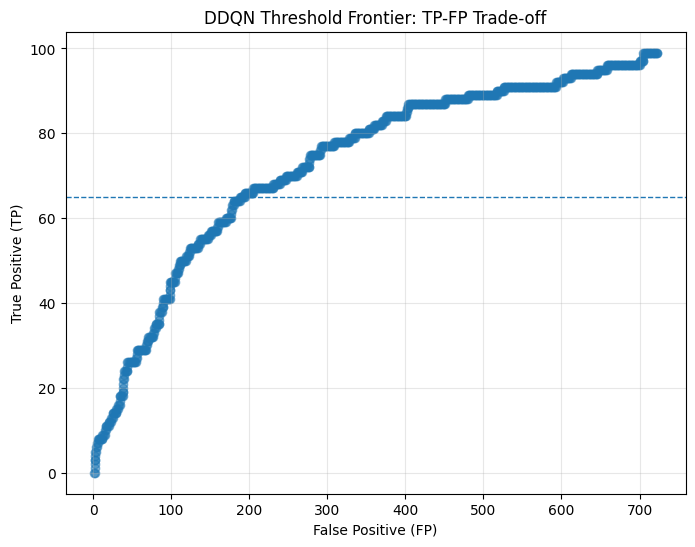

In [3]:
# ============================================================
# Threshold Frontier Check
# 현재 학습된 DDQN Q-margin에서 TP >= 65를 유지하면서 FP 최소 확인
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

TARGET_TP_MIN = 65

# 현재 DDQN 모델의 test Q-margin 계산
# Q-margin = Q(High Risk) - Q(Low Risk)
test_margins = get_q_margin(agent.online_net, test_feature)

# threshold 후보:
# 실제 예측이 바뀌는 지점 + 현재 선택된 Q_THRESHOLD 포함
threshold_grid = np.unique(np.r_[test_margins, Q_THRESHOLD, 0.0])

frontier_records = []

for th in threshold_grid:
    pred = (test_margins >= th).astype(int)

    tn, fp, fn, tp = confusion_matrix(test_label, pred, labels=[0, 1]).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    f1 = (
        2 * precision * sensitivity / (precision + sensitivity)
        if (precision + sensitivity) > 0 else 0.0
    )
    gmean = np.sqrt(sensitivity * specificity)

    frontier_records.append({
        "threshold": float(th),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "sensitivity": float(sensitivity),
        "specificity": float(specificity),
        "precision": float(precision),
        "f1": float(f1),
        "gmean": float(gmean),
        "pred_1_count": int(tp + fp)
    })

frontier_df = pd.DataFrame(frontier_records)

# 같은 TP에서 FP가 더 큰 중복 후보는 보기 어렵기 때문에 정렬
frontier_df = frontier_df.sort_values(
    by=["tp", "fp", "threshold"],
    ascending=[False, True, False]
).reset_index(drop=True)

print("=" * 80)
print("전체 threshold frontier 요약")
print("=" * 80)
print(f"전체 threshold 후보 수: {len(frontier_df)}")
print(f"Test 실제 class 1 개수: {(test_label == 1).sum()}")
print(f"TP 최소 조건: TP >= {TARGET_TP_MIN}")
print("=" * 80)

# 현재 사용 중인 Q_THRESHOLD에 가장 가까운 결과 확인
current_idx = (frontier_df["threshold"] - Q_THRESHOLD).abs().idxmin()
current_row = frontier_df.loc[current_idx]

print("\n[현재 Q_THRESHOLD 기준 결과]")
print(f"Q_THRESHOLD = {Q_THRESHOLD:.6f}")
print(
    f"TN={int(current_row['tn'])}, FP={int(current_row['fp'])}, "
    f"FN={int(current_row['fn'])}, TP={int(current_row['tp'])}"
)
print(
    f"Sens={current_row['sensitivity']:.4f}, "
    f"Spec={current_row['specificity']:.4f}, "
    f"Prec={current_row['precision']:.4f}, "
    f"F1={current_row['f1']:.4f}, "
    f"G-mean={current_row['gmean']:.4f}"
)

# TP >= 65 조건을 만족하는 후보만 필터링
feasible_df = frontier_df[frontier_df["tp"] >= TARGET_TP_MIN].copy()

print("\n" + "=" * 80)
print(f"TP >= {TARGET_TP_MIN} 조건을 만족하는 threshold 후보")
print("=" * 80)

if feasible_df.empty:
    print(f"TP >= {TARGET_TP_MIN} 조건을 만족하는 threshold가 없습니다.")
    print("즉, 현재 DDQN 점수 구조에서는 threshold만 조정해서 TP 65 이상을 만들 수 없습니다.")
else:
    # 목표 조건 안에서 FP 최소
    # 동률이면 precision 높은 것, gmean 높은 것, TP 높은 것 순으로 선택
    best_fp_row = feasible_df.sort_values(
        by=["fp", "precision", "gmean", "tp"],
        ascending=[True, False, False, False]
    ).iloc[0]

    print("\n[TP 조건 유지하에서 FP 최소 threshold]")
    print(f"threshold = {best_fp_row['threshold']:.6f}")
    print(
        f"TN={int(best_fp_row['tn'])}, FP={int(best_fp_row['fp'])}, "
        f"FN={int(best_fp_row['fn'])}, TP={int(best_fp_row['tp'])}"
    )
    print(
        f"Sens={best_fp_row['sensitivity']:.4f}, "
        f"Spec={best_fp_row['specificity']:.4f}, "
        f"Prec={best_fp_row['precision']:.4f}, "
        f"F1={best_fp_row['f1']:.4f}, "
        f"G-mean={best_fp_row['gmean']:.4f}"
    )

    print("\n[TP >= 65 조건에서 FP가 낮은 상위 20개 후보]")
    display(
        feasible_df.sort_values(
            by=["fp", "precision", "gmean", "tp"],
            ascending=[True, False, False, False]
        ).head(20)
    )

# 보기 좋은 frontier: TP별 FP 최소 후보만 출력
tp_fp_frontier = (
    frontier_df
    .sort_values(by=["tp", "fp"], ascending=[False, True])
    .groupby("tp", as_index=False)
    .first()
    .sort_values(by="tp", ascending=False)
    .reset_index(drop=True)
)

print("\n" + "=" * 80)
print("TP별 FP 최소 frontier")
print("=" * 80)
display(tp_fp_frontier[tp_fp_frontier["tp"] >= 50].head(60))

# 시각화: TP-FP trade-off
plt.figure(figsize=(8, 6))
plt.scatter(frontier_df["fp"], frontier_df["tp"], alpha=0.5)
plt.axhline(TARGET_TP_MIN, linestyle="--", linewidth=1)
plt.xlabel("False Positive (FP)")
plt.ylabel("True Positive (TP)")
plt.title("DDQN Threshold Frontier: TP-FP Trade-off")
plt.grid(True, alpha=0.3)
plt.show()

In [4]:
# Test 구간 날짜 인덱스
from pathlib import Path

test_dates = dat.index[test_indices]

# 최종 선택된 Q_THRESHOLD 기준 test_predictions 저장
# 저장 컬럼: Date + Predicted_Action
result_dir = Path("../../results/results_RL")
result_dir.mkdir(parents=True, exist_ok=True)

output_test_csv_path = result_dir / "DDQN_predictions12.csv"

test_predicted_actions_df = pd.DataFrame({
    "Date": test_dates,
    "Predicted_Action": test_predictions
})

test_predicted_actions_df.to_csv(output_test_csv_path, index=False)

print(f"Test 구간 예측 결과가 '{output_test_csv_path}' 파일로 저장되었습니다.")
display(test_predicted_actions_df.head())


Test 구간 예측 결과가 '..\..\results\results_RL\DDQN_predictions12.csv' 파일로 저장되었습니다.


,Date,Predicted_Action
0,2022-10-17,0
1,2022-10-18,0
2,2022-10-19,1
3,2022-10-20,1
4,2022-10-21,0


In [5]:
# ============================================================
# DDQN8 threshold recall_floor 후보 비교
# 재학습 없이 valid_select에서 threshold만 다시 선택해서 test 성능 확인
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

def evaluate_threshold_from_margin(margins, y_true, threshold):
    pred = (margins >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    f1 = (
        2 * precision * sensitivity / (precision + sensitivity)
        if (precision + sensitivity) > 0 else 0.0
    )
    gmean = np.sqrt(sensitivity * specificity)

    return {
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "sensitivity": float(sensitivity),
        "specificity": float(specificity),
        "precision": float(precision),
        "f1": float(f1),
        "gmean": float(gmean),
        "pred_1_count": int(tp + fp),
    }

valid_margins = get_q_margin(agent.online_net, valid_select_feature)
test_margins = get_q_margin(agent.online_net, test_feature)

recall_floors = [0.62, 0.65, 0.68, 0.70, 0.72, 0.75]

rows = []

for rf in recall_floors:
    threshold_info, threshold_search_df, threshold_candidate_df = select_threshold_by_recall_fp(
        agent.online_net,
        valid_select_feature,
        valid_select_label,
        recall_floor=rf
    )

    th = float(threshold_info["threshold"])

    valid_metrics = evaluate_threshold_from_margin(
        valid_margins,
        valid_select_label,
        th
    )

    test_metrics = evaluate_threshold_from_margin(
        test_margins,
        test_label,
        th
    )

    rows.append({
        "recall_floor": rf,
        "threshold": th,

        "valid_tn": valid_metrics["tn"],
        "valid_fp": valid_metrics["fp"],
        "valid_fn": valid_metrics["fn"],
        "valid_tp": valid_metrics["tp"],
        "valid_sens": valid_metrics["sensitivity"],
        "valid_prec": valid_metrics["precision"],
        "valid_f1": valid_metrics["f1"],
        "valid_gmean": valid_metrics["gmean"],

        "test_tn": test_metrics["tn"],
        "test_fp": test_metrics["fp"],
        "test_fn": test_metrics["fn"],
        "test_tp": test_metrics["tp"],
        "test_sens": test_metrics["sensitivity"],
        "test_prec": test_metrics["precision"],
        "test_f1": test_metrics["f1"],
        "test_gmean": test_metrics["gmean"],
        "test_pred_1_count": test_metrics["pred_1_count"],
    })

recall_floor_compare_df = pd.DataFrame(rows)

display(
    recall_floor_compare_df.sort_values(
        by=["test_gmean", "test_f1", "test_fp"],
        ascending=[False, False, True]
    )
)

,recall_floor,threshold,valid_tn,valid_fp,valid_fn,valid_tp,valid_sens,valid_prec,valid_f1,valid_gmean,test_tn,test_fp,test_fn,test_tp,test_sens,test_prec,test_f1,test_gmean,test_pred_1_count
5,0.75,-0.196813,242,185,18,59,0.766234,0.241803,0.367601,0.658983,528,195,33,66,0.666667,0.252874,0.366667,0.697754,261
4,0.72,-0.142996,270,157,21,56,0.727273,0.262911,0.386207,0.678136,565,158,42,57,0.575758,0.265116,0.363057,0.670772,215
2,0.68,-0.124167,277,150,23,54,0.701299,0.264706,0.384342,0.674493,576,147,44,55,0.555556,0.272277,0.365449,0.665282,202
3,0.70,-0.124167,277,150,23,54,0.701299,0.264706,0.384342,0.674493,576,147,44,55,0.555556,0.272277,0.365449,0.665282,202
1,0.65,-0.058590,299,128,26,51,0.662338,0.284916,0.398438,0.681022,603,120,48,51,0.515152,0.298246,0.377778,0.655476,171
0,0.62,-0.040899,305,122,29,48,0.623377,0.282353,0.388664,0.667285,610,113,49,50,0.505051,0.306748,0.381679,0.652774,163
